# Copy-Trading Framework & Ranking Leaderboard
In this notebook, we design a quantitative scoring model to score, tier, and rank accounts for copy-trading. We then simulate copying the trades of top-tier accounts to construct an equity curve.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent
CSV = ROOT / 'csv_files'
OUT = ROOT / 'outputs'
plt.style.use('seaborn-v0_8-whitegrid')

## Load Account Profiles & Scoring Framework
We construct scores across profitability, consistency, volume, recency, and wash-trading probability.

In [2]:
acc = pd.read_csv(ROOT / 'data' / 'advanced_account_metrics.csv')
wash = pd.read_csv(ROOT / 'data' / 'wash_trading_heuristics.csv')

acc = acc.merge(wash[['Account', 'human_probability', 'wash_suspicion_score']], on='Account', how='left')

def pct_rank(s):
    return s.rank(pct=True).fillna(0)

acc['trade_count_score'] = 100 * pct_rank(np.log1p(acc['trades']))
acc['win_rate_score'] = 100 * (acc['win_rate'] / 100.0).clip(0, 1)
acc['profit_factor_score'] = 100 * pct_rank(acc['avg_pnl'] / acc['pnl_std'].replace(0, np.nan).fillna(1))
acc['consistency_score'] = 100 * (1 - pct_rank(acc['pnl_std'].fillna(acc['pnl_std'].median()))).clip(0, 1)
acc['recency_score'] = 100.0 # Default full score since we look at complete active sets

# Composite Score
acc['copy_score'] = (
    0.20 * acc['trade_count_score'] +
    0.25 * acc['win_rate_score'] +
    0.25 * acc['profit_factor_score'] +
    0.15 * acc['consistency_score'] +
    0.10 * acc['recency_score'] +
    0.05 * 100.0 * acc['human_probability']
)

acc['copy_tier'] = pd.cut(
    acc['copy_score'],
    bins=[-np.inf, 40, 60, 80, np.inf],
    labels=['Reject', 'Watchlist', 'Good', 'Excellent']
)

acc.sort_values('copy_score', ascending=False).to_csv(CSV / 'copy_trading_scores.csv', index=False)
acc.sort_values('copy_score', ascending=False).to_csv(ROOT / 'data' / 'copy_trading_scores.csv', index=False)
acc.sort_values('copy_score', ascending=False).head(10)

,Account,trades,win_rate,avg_pnl,pnl_std,total_pnl,volume,maker_rate,taker_rate,avg_fee,...,cluster,human_probability,wash_suspicion_score,trade_count_score,win_rate_score,profit_factor_score,consistency_score,recency_score,copy_score,copy_tier
9,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,0.810876,39.750362,113.554346,3.790954e+05,2.572950e+07,0.682503,0.317497,0.262333,...,3,0.75,0.25,78.125,0.810876,71.875,68.750,100.0,57.858969,Watchlist
17,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15604,0.345809,7.193168,33.942635,1.063029e+05,1.986821e+07,0.895347,0.104653,0.146626,...,3,0.75,0.25,93.750,0.345809,40.625,96.875,100.0,57.273952,Watchlist
2,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,0.467582,31.234747,114.126486,9.401638e+05,6.803634e+07,0.673603,0.326397,0.405658,...,3,0.50,0.50,96.875,0.467582,46.875,62.500,100.0,53.085646,Watchlist
14,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13301,0.438914,11.116521,57.784087,1.324648e+05,6.757020e+06,0.054582,0.945418,0.166782,...,3,0.75,0.25,84.375,0.438914,31.250,87.500,100.0,51.672229,Watchlist
10,0x4f93fead39b70a1824f981a54d4e55b278e9f760,7562,0.361412,56.918722,170.377739,3.089759e+05,1.296725e+08,0.000000,1.000000,5.385410,...,2,0.75,0.25,71.875,0.361412,68.750,37.500,100.0,51.027853,Watchlist
18,0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8513,0.353694,14.236428,69.964140,1.033437e+05,4.408828e+06,0.294491,0.705509,0.144584,...,3,0.75,0.25,75.000,0.353694,37.500,81.250,100.0,50.400924,Watchlist
4,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40172,0.428358,18.775546,103.078260,8.360806e+05,7.410781e+07,0.251394,0.748606,0.332393,...,3,0.75,0.25,100.000,0.428358,21.875,71.875,100.0,50.107090,Watchlist
0,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14719,0.337455,48.330058,169.345425,2.143383e+06,5.653128e+07,0.158299,0.841701,1.086504,...,3,0.75,0.25,87.500,0.337455,50.000,40.625,100.0,49.928114,Watchlist
5,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4355,0.486338,79.631816,213.621604,6.777471e+05,3.957295e+07,0.442021,0.557979,1.842937,...,1,0.75,0.25,59.375,0.486338,81.250,21.875,100.0,49.340334,Watchlist
1,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,0.359612,122.356302,301.263979,1.600230e+06,6.169726e+07,0.887899,0.112101,1.939579,...,0,1.00,0.00,56.250,0.359612,87.500,3.125,100.0,48.683653,Watchlist


## Simulate Copy-Trading Portfolio
We select the top 5 'Excellent' tier accounts and backtest copying their trades.

Top traders trade count: 67552
Total PnL from Copy-Trading: 1,867,002.77 USD
Copy-Trading Portfolio Profit Factor: 6.934


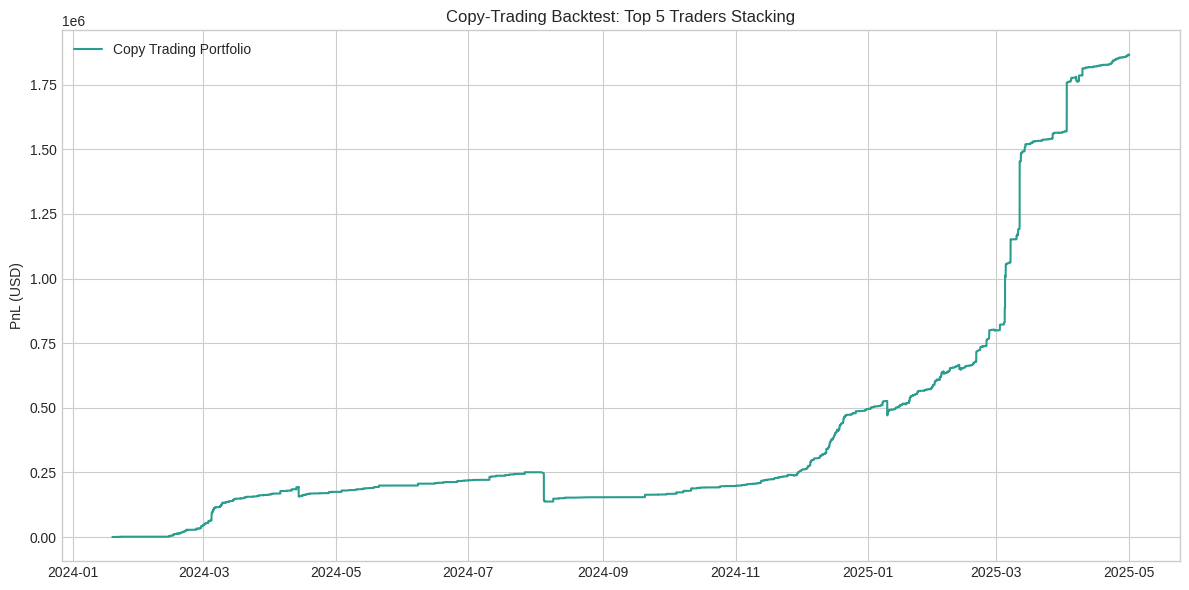

In [3]:
top_traders = acc.sort_values('copy_score', ascending=False).head(5)['Account'].tolist()
df_trades = pd.read_csv(ROOT / 'data' / 'historical_with_features.csv')
df_trades['timestamp_utc'] = pd.to_datetime(df_trades['timestamp_utc'])

# Filter trades from top traders
top_trades = df_trades[df_trades['Account'].isin(top_traders)].sort_values('timestamp_utc').copy()
top_trades['cum_pnl'] = top_trades['Closed PnL'].cumsum()
top_trades['roll_max'] = top_trades['cum_pnl'].cummax()
top_trades['drawdown'] = top_trades['cum_pnl'] - top_trades['roll_max']

print(f"Top traders trade count: {len(top_trades)}")
print(f"Total PnL from Copy-Trading: {top_trades['Closed PnL'].sum():,.2f} USD")
print(f"Copy-Trading Portfolio Profit Factor: {top_trades[top_trades['Closed PnL']>0]['Closed PnL'].sum() / abs(top_trades[top_trades['Closed PnL']<0]['Closed PnL'].sum()):.3f}")

plt.figure(figsize=(12, 6))
plt.plot(top_trades['timestamp_utc'], top_trades['cum_pnl'], color='#2a9d8f', label='Copy Trading Portfolio')
plt.title('Copy-Trading Backtest: Top 5 Traders Stacking')
plt.ylabel('PnL (USD)')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'figures/copy_trading_portfolio.png', dpi=180)
plt.show()